In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from numba import njit
from pyHockneySolver import solve_open_poisson_hockney

np.random.seed(33)

## Constants & Parameters

In [207]:
# PHYSICAl CONSTANTS

# M_E = 9.1093837015e-31 # electron mass in kg
M_E = 0.511 # electron mass in MeV/c^2
Q_E_SI = -1.602176634e-19 # electron charge in C
Q_E = -1. # electron charge in e
EPSILON_0 = 5.5263494e13  # vacuum permittivity in in e/(MV*m)
C = 299792458 # speed of light in m/s


# HYPERPARAMETERS

SIGMA_X=1e-3 # standard deviation of initial x position in m
SIGMA_Y=1e-3 # standard deviation of initial y position in m
SIGMA_Z=0.1 # standard deviation of initial z position in m

SIGMA_PX=1e-9 # standard deviation of initial x momentum in MeV/c
SIGMA_PY=1e-9 # standard deviation of initial y momentum in MeV/c
SIGMA_PZ=1e-2 # standard deviation of initial z momentum in MeV/c


LENGTH_PRIOR = 0.5 # length of prior region to be modeled in m
LENGTH_D = 0.25 # length of drift chamber in m
LENGTH_E = 3.75 # length of electric field chamber in m
LENGTH_POSTERIOR = 1.5 # length of posterior region to be modeled in m

RADIUS_X = 0.05 # width of model space in x direction in m
RADIUS_Y = 0.05 # width of model space in y direction in m


E_Z = -1. # electric field strength in MV/m

N_P = int(1e2) # number of macro particles
TOTAL_CHARGE_SI = 1e-9 # total bunch charge in C

DELTA_POS = 1e-2  # spacing of z-grid (Fields, Space Charge, etc.) in m
DELTA_T = 2e-11 # time step in s    CFL-Condition: DELTA_T < DELTA_Z / C
T_MAX = 1e-7 # maximum simulation time in s


# DERIVED QUANTITIES

POSITION_SIGMA = (SIGMA_X, SIGMA_Y, SIGMA_Z)
MOMENTUM_SIGMA = (SIGMA_PX, SIGMA_PY, SIGMA_PZ)

Z_START = 0. # start of model space
Z_0 = Z_START + LENGTH_PRIOR # initial z position of particles
Z_1 = Z_START + LENGTH_PRIOR + LENGTH_D # z position of end of drift chamber = start of electric field chamber
Z_2 = Z_START + LENGTH_PRIOR + LENGTH_D + LENGTH_E # z position of end of electric field chamber
Z_END = Z_2 + LENGTH_POSTERIOR # end of model space

POSITION_0 = (0., 0., Z_0) # initial position (of reference particle) in m
MOMENTUM_0 = (0., 0., 0.1) # initial momentum in MeV/c

N_REAL_ELECTRONS = TOTAL_CHARGE_SI / Q_E_SI # number of real electrons in the bunch
MACRO_WEIGHT = N_REAL_ELECTRONS / N_P 

M_MACRO = M_E * MACRO_WEIGHT
Q_MACRO = Q_E * MACRO_WEIGHT


X_GRID = np.arange(-RADIUS_X, RADIUS_X + DELTA_POS, DELTA_POS)
Y_GRID = np.arange(-RADIUS_Y, RADIUS_Y + DELTA_POS, DELTA_POS)
Z_GRID = np.arange(Z_START, Z_END + DELTA_POS, DELTA_POS)

N_X, N_Y, N_Z = len(X_GRID), len(Y_GRID), len(Z_GRID)

POSITION_GRID = np.meshgrid(X_GRID, Y_GRID, Z_GRID, indexing='ij')

E_EXT_GRID = np.zeros_like(POSITION_GRID)
E_EXT_GRID[:, :, :, (Z_GRID >= Z_1) & (Z_GRID <= Z_2)] = E_Z

assert DELTA_T < DELTA_POS / C, "CFL condition violated: DELTA_T must be less than DELTA_Z / C"

## Plotting Helper

In [208]:
AX_NAMES = ['x', 'y', 'z']

def PLOT_particles(positions, momenta, title="Particle Distribution"):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for i in range(3):
        axes[i].scatter(positions[i], momenta[i], alpha=0.5)
        axes[i].set_title(title)
        axes[i].set_xlabel(f'{AX_NAMES[i]} (m)')
        axes[i].set_ylabel(f'p_{AX_NAMES[i]} (MeV/c)')
        axes[i].grid()

def PLOT_particles_3D(positions, title="Particle Distribution"):
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(positions[0], positions[1], positions[2], alpha=0.5)
    ax.plot(np.zeros(N_Z), np.zeros(N_Z), Z_GRID, alpha=0.5, color='black', label='z-axis')
    ax.plot(np.zeros(N_Y), Y_GRID, np.full(N_Y, POSITION_0[2]), alpha=0.5, color='red', label='y-axis')
    ax.plot(X_GRID, np.zeros(N_X), np.full(N_X, POSITION_0[2]), alpha=0.5, color='blue', label='x-axis')
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_zlabel('z (m)')

    plt.show()

def PLOT_rho_3D(rho_grid, title="Charge Density"):
    # make a 3D plot of the charge density with shape (N_X, N_Y, N_Z) using matplotlib
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    X, Y, Z = POSITION_GRID
    ax.scatter(X.flatten(), Y.flatten(), Z.flatten(), c=rho_grid.flatten(), cmap='viridis', marker='o')
    ax.set_title(title)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_zlabel('z (m)')
    # ax.set_aspect('equal')
    plt.show()

## Solver Helper

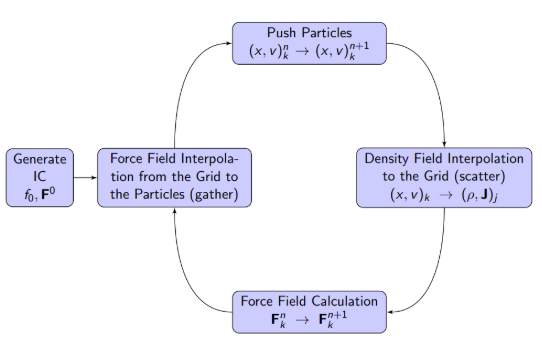
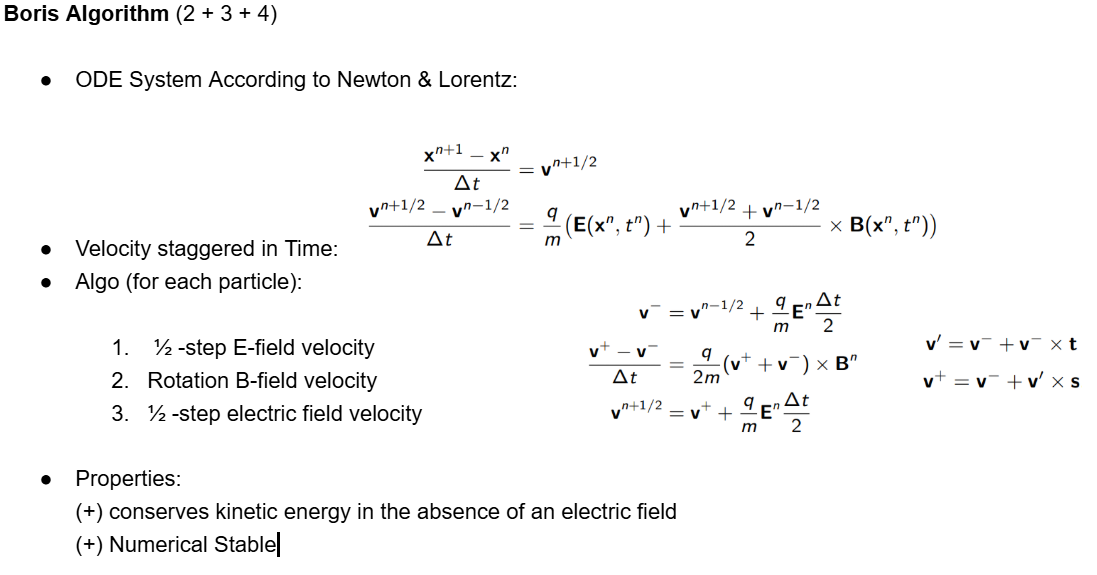
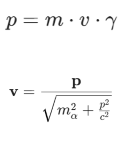
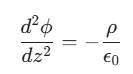
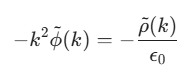
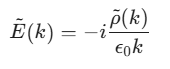
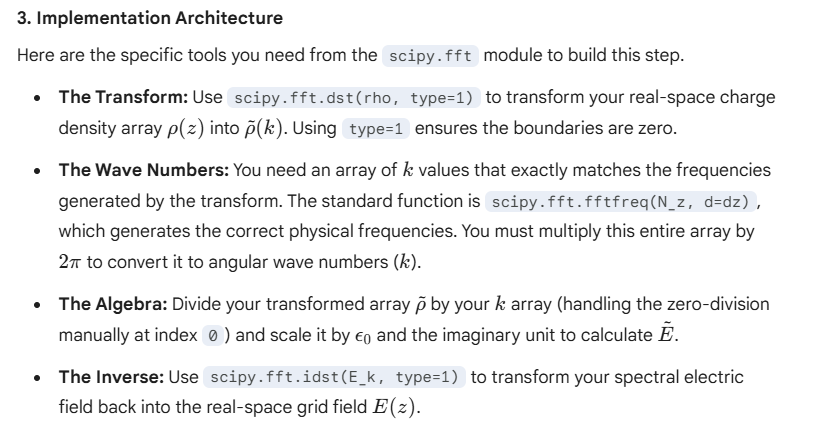

In [ ]:
def gather_field(position_particles, E_grid):
    ''' 
    Interpolate electric field values from grid to particle positions
    '''

    E_particles = np.interp(position_particles, POSITION_GRID, E_grid)
    
    return E_particles
    


@njit
def scatter_charge_3d_numba(position_particles):
    '''
    Calculate charge density on grid from particle positions

    Heavily inspired by Gemini 3 AI (!) 
    '''
    # Allocate the 3D grid directly (Numba handles this efficiently)
    rho_grid = np.zeros((N_X, N_Y, N_Z), dtype=np.float64)
    
    # Loop over every particle
    for i_P in range(N_P):
        x = position_particles[0, i_P]
        y = position_particles[1, i_P]
        z = position_particles[2, i_P]
        
        # Fractional grid indices
        i_x_float = (x - POSITION_0[0]) / DELTA_POS
        i_y_float = (y - POSITION_0[1]) / DELTA_POS
        i_z_float = (z - POSITION_0[2]) / DELTA_POS
        
        # Integer coordinates of the cell's lower-left-front corner
        i_x = int(math.floor(i_x_float))
        i_y = int(math.floor(i_y_float))
        i_z = int(math.floor(i_z_float))
            
        # Fractional distances to the next grid point
        frac_x_1 = i_x_float - i_x
        frac_y_1 = i_y_float - i_y
        frac_z_1 = i_z_float - i_z
        
        # Fractional distances to the previous grid point
        frac_x = 1.0 - frac_x_1
        frac_y = 1.0 - frac_y_1
        frac_z = 1.0 - frac_z_1
        
        # 3. Add charge directly to the 8 corners of the 3D cell
        rho_grid[i_x,   i_y,   i_z  ] += Q_MACRO * (frac_x * frac_y * frac_z)
        rho_grid[i_x+1, i_y,   i_z  ] += Q_MACRO * (frac_x_1 * frac_y * frac_z)
        rho_grid[i_x,   i_y+1, i_z  ] += Q_MACRO * (frac_x * frac_y_1 * frac_z)
        rho_grid[i_x+1, i_y+1, i_z  ] += Q_MACRO * (frac_x_1 * frac_y_1 * frac_z)
        rho_grid[i_x,   i_y,   i_z+1] += Q_MACRO * (frac_x * frac_y * frac_z_1)
        rho_grid[i_x+1, i_y,   i_z+1] += Q_MACRO * (frac_x_1 * frac_y * frac_z_1)
        rho_grid[i_x,   i_y+1, i_z+1] += Q_MACRO * (frac_x * frac_y_1 * frac_z_1)
        rho_grid[i_x+1, i_y+1, i_z+1] += Q_MACRO * (frac_x_1 * frac_y_1 * frac_z_1)

    # 4. Divide by cell volume to get density
    volume_cell = DELTA_POS**3
    rho_grid = rho_grid / volume_cell
    
    return rho_grid

def solve_E_int(rho_grid):
    ''' 
    Solve for internal electric field grid from charge density grid
    '''

    ... # Not needed

def solve_E_tot(rho_grid):
    '''
    Calculate total electric field grid
    '''

    E_int_grid = solve_E_int(rho_grid)

    E_ext_grid = np.zeros_like(rho_grid)

    E_tot_grid = E_int_grid + E_EXT_GRID

    return E_tot_grid
        
def velocity_particles_SI(p_particles):
    '''
    Calculate particle velocity from momentum using relativistic formula
    '''
    gamma = np.sqrt(1 + (p_particles / M_E)**2)
    v = p_particles / (gamma * M_E) * C # convert from MeV/c to m/s
    return v


def push_particles(position_particles, momentum_stag_particles, E_particles):
    '''
    Update particle positions and momenta based on electric field
    '''

    # Using Velocity Verlet integration for better accuracy and stability
    # TODO In 3D, use Boris push

    next_momentum_stag_particles = momentum_stag_particles + Q_E * E_particles * (C*DELTA_T)
    next_velocity_stag_particles = velocity_particles_SI(next_momentum_stag_particles)
    next_position_particles = position_particles + next_velocity_stag_particles * DELTA_T

    return next_position_particles, next_momentum_stag_particles


    

In [210]:
print(POSITION_0)

(0.0, 0.0, 0.5)


## Initialization

In [211]:
position_particles = np.random.normal(POSITION_0, POSITION_SIGMA, (N_P, 3)).T
momentum_particles = np.random.normal(MOMENTUM_0, MOMENTUM_SIGMA, (N_P, 3)).T
position_particles.shape

(3, 100)

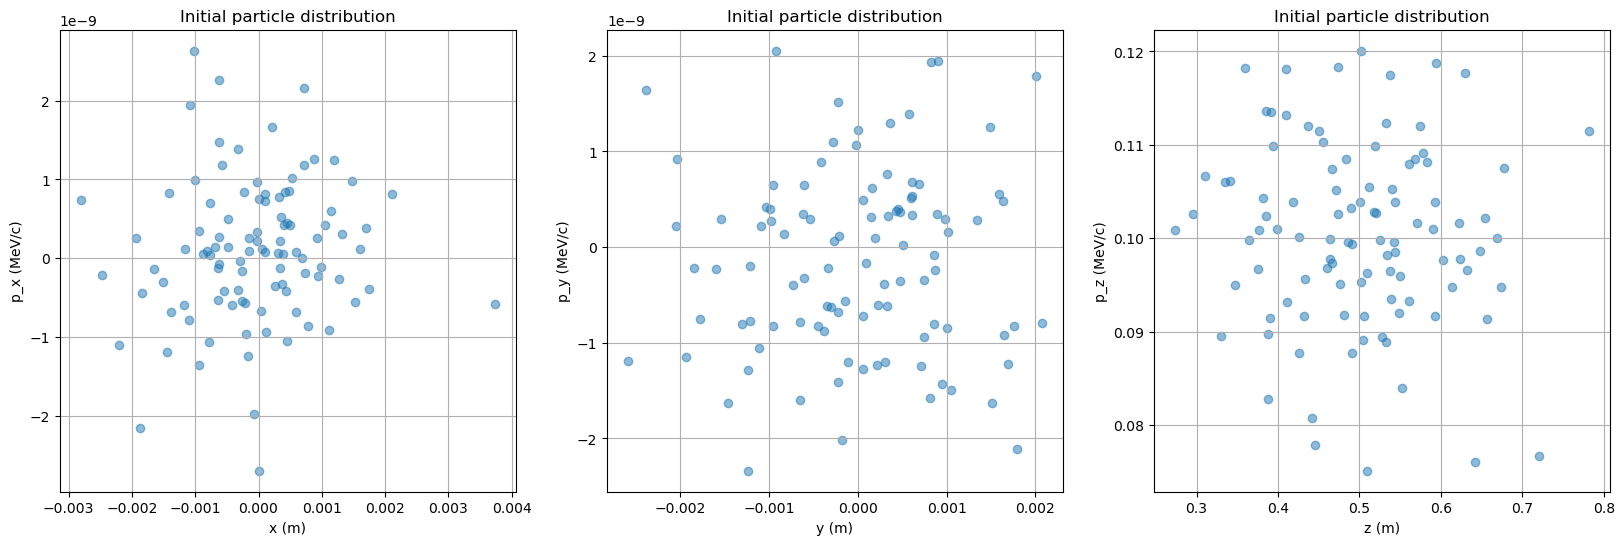

In [212]:
PLOT_particles(position_particles, momentum_particles, 'Initial particle distribution')

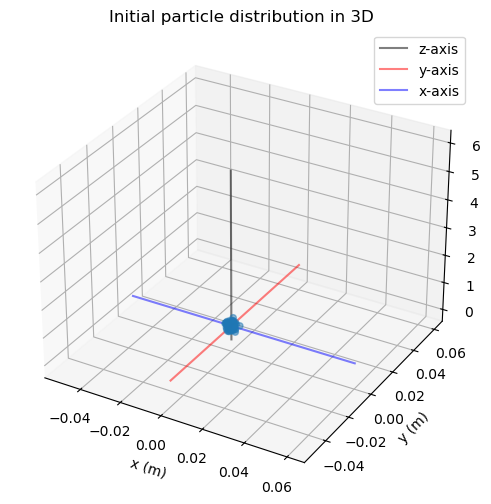

In [213]:
PLOT_particles_3D(position_particles, 'Initial particle distribution in 3D')

## INTEGRATION LOOP

In [214]:
# Initialize staggered Momentum 

# TODO In 3D, transform into (quasi) rest frame here
# position_particles_rest, momentum_particles_rest = transform_to_rest(position_particles, momentum_particles)
rho_grid = scatter_charge(position_particles)
E_tot_grid = solve_E_tot(rho_grid) 
# TODO In 3D, transform back to lab frame here (?)
E_particles = gather_field(position_particles, E_tot_grid)

momentum_stag_particles = momentum_particles - Q_E * E_particles * (C*DELTA_T) / 2 # staggered momentum for Velocity Verlet

AssertionError: 

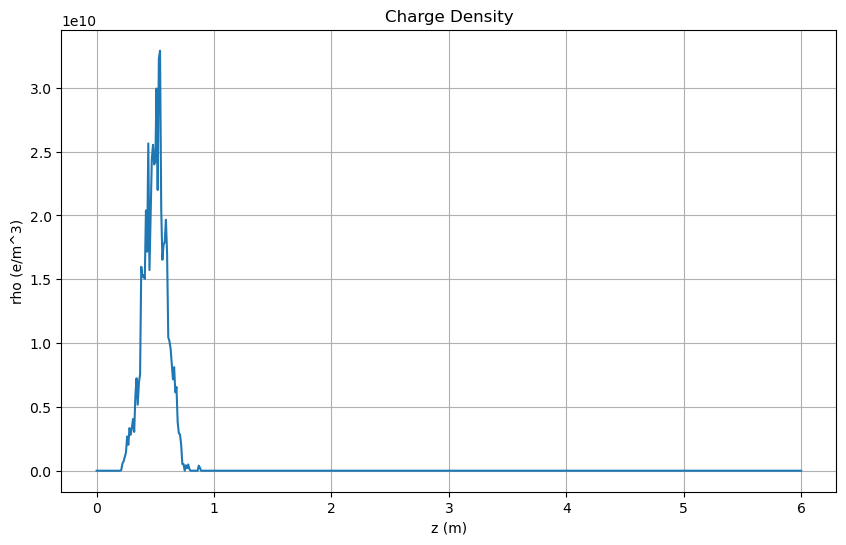

In [ ]:
PLOT_rho(position_grid, rho_grid)

In [ ]:
# Main integration loop

nums_particles = [N_P]
times = [0.]
position_means = [np.mean(position_particles)]
momentum_stag_means = [np.mean(momentum_stag_particles)]
position_sigmas = [np.std(position_particles)]
momentum_stag_sigmas = [np.std(momentum_stag_particles)]

z_mean = position_means[-1]
t = 0.
while z_mean < Z_2 and t < T_MAX:

    # TODO In 3D, transform into (quasi) rest frame here
    rho_grid = scatter_charge(position_particles)
    E_tot_grid = solve_E_tot(rho_grid)
    # TODO In 3D, transform back to lab frame here (?)
    E_particles = gather_field(position_particles, E_tot_grid)
    position_particles, momentum_stag_particles = push_particles(position_particles, momentum_stag_particles, E_particles)


    # Handle lost particles
    valid_mask = (position_particles >= Z_START) & (position_particles < Z_END)
    position_particles = position_particles[valid_mask]
    momentum_stag_particles = momentum_stag_particles[valid_mask]
    current_num_particles = len(position_particles)


    times.append(t)
    position_means.append(np.mean(position_particles))
    momentum_stag_means.append(np.mean(momentum_stag_particles))
    position_sigmas.append(np.std(position_particles))
    momentum_stag_sigmas.append(np.std(momentum_stag_particles))


    nums_particles.append(current_num_particles)
    z_mean = position_means[-1]
    t += DELTA_T 


## PLOTTING

In [ ]:
times = np.array(times)
times_stag = times - DELTA_T / 2
position_means = np.array(position_means) - Z_0
momentum_stag_means = np.array(momentum_stag_means)
position_sigmas = np.array(position_sigmas)
momentum_stag_sigmas = np.array(momentum_stag_sigmas)

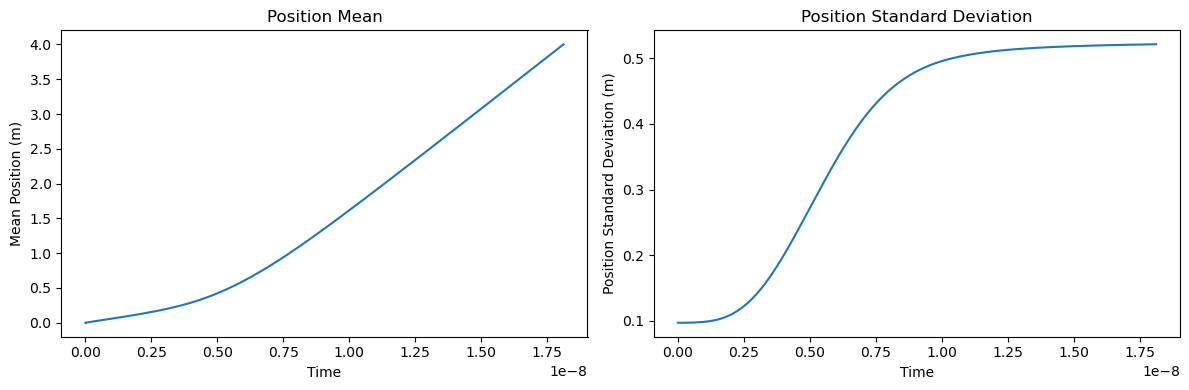

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(times, position_means)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Mean Position (m)')
axes[0].set_title('Position Mean')

axes[1].plot(times, position_sigmas)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Position Standard Deviation (m)')
axes[1].set_title('Position Standard Deviation')


fig.tight_layout()
plt.show()

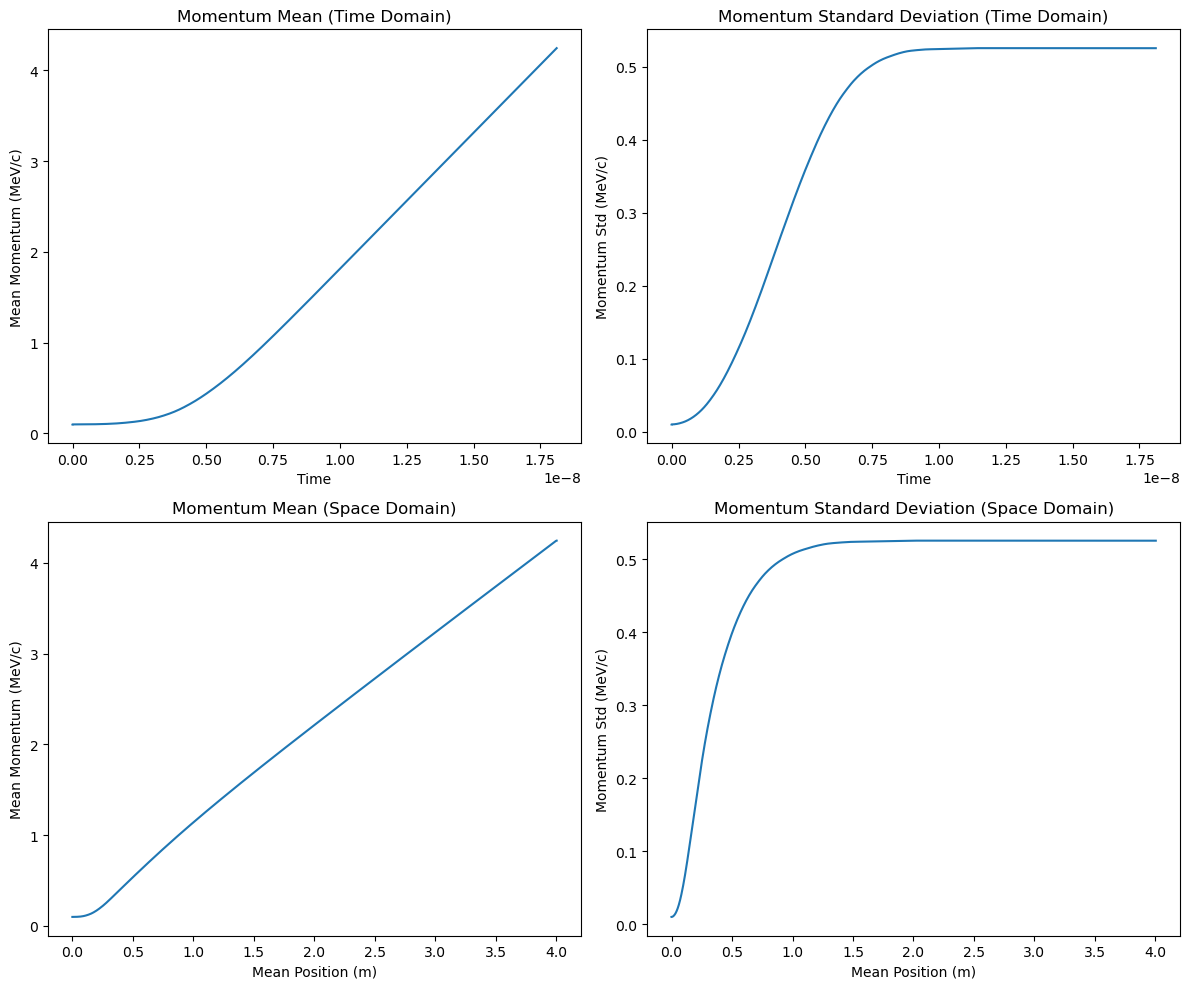

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(times_stag, momentum_stag_means)
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Mean Momentum (MeV/c)')
axes[0, 0].set_title('Momentum Mean (Time Domain)')

axes[0, 1].plot(times_stag, momentum_stag_sigmas)
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Momentum Std (MeV/c)')
axes[0, 1].set_title('Momentum Standard Deviation (Time Domain)')

momentum_means_interp = np.interp(times, times_stag, momentum_stag_means)
momentum_sigmas_interp = np.interp(times, times_stag, momentum_stag_sigmas)

axes[1, 0].plot(position_means, momentum_means_interp)
axes[1, 0].set_xlabel('Mean Position (m)')
axes[1, 0].set_ylabel('Mean Momentum (MeV/c)')
axes[1, 0].set_title('Momentum Mean (Space Domain)')

axes[1, 1].plot(position_means, momentum_sigmas_interp)
axes[1, 1].set_xlabel('Mean Position (m)')
axes[1, 1].set_ylabel('Momentum Std (MeV/c)')
axes[1, 1].set_title('Momentum Standard Deviation (Space Domain)')

fig.tight_layout()
plt.show()

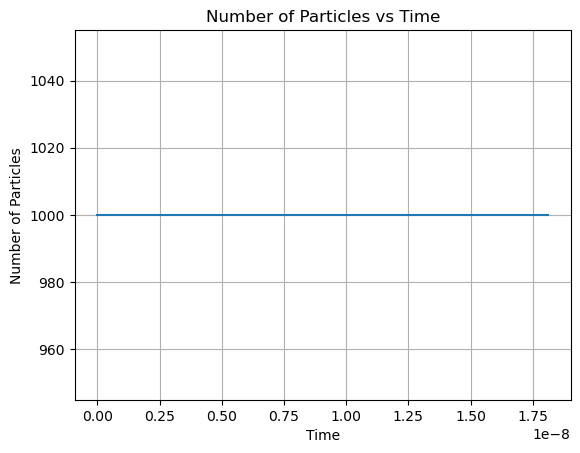

In [ ]:
plt.plot(times, nums_particles)
plt.xlabel('Time')
plt.ylabel('Number of Particles')
plt.title('Number of Particles vs Time')
plt.grid()

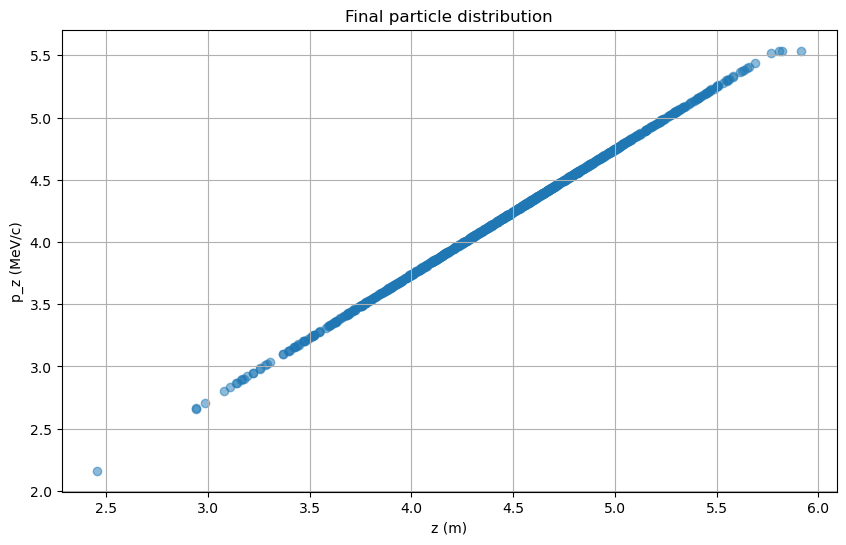

In [ ]:
PLOT_particles(position_particles, momentum_stag_particles, 'Final particle distribution')

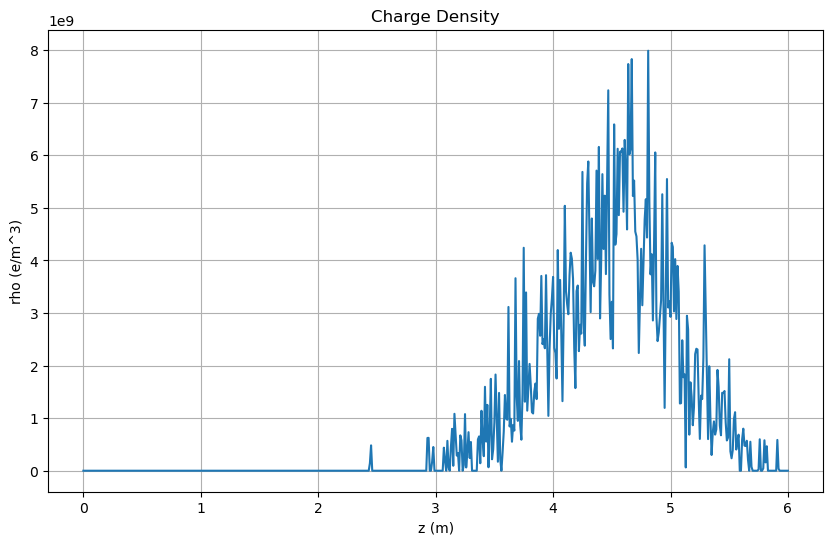

In [ ]:
PLOT_rho(rho_grid)